In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv('Spotify_Streaming_Performance.csv')

In [10]:
df.head

<bound method NDFrame.head of        Artist Name     Sex Country of Origin Primary Language Primary Genre  \
0            Drake    Male            Canada          English       Hip-Hop   
1     Taylor Swift  Female     United States          English           Pop   
2        Bad Bunny    Male     United States          Spanish     Reggaeton   
3       The Weeknd    Male            Canada          English           R&B   
4    Justin Bieber    Male            Canada          English           Pop   
..             ...     ...               ...              ...           ...   
495       The Cure    Male    United Kingdom          English          Rock   
496     The Marías   Mixed     United States          English           Pop   
497    Limp Bizkit    Male     United States          English      Nu Metal   
498           Korn    Male     United States          English         Metal   
499    Omar Courtz    Male     United States          Spanish     Reggaeton   

     Artist Type  Deb

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Artist Name                          500 non-null    object 
 1   Sex                                  500 non-null    object 
 2   Country of Origin                    500 non-null    object 
 3   Primary Language                     500 non-null    object 
 4   Primary Genre                        500 non-null    object 
 5   Artist Type                          500 non-null    object 
 6   Debut Year                           500 non-null    int64  
 7   Total Streams (in millions)          500 non-null    float64
 8   Lead Streams (in millions)           500 non-null    float64
 9   Feature Streams (in millions)        500 non-null    float64
 10  Solo Streams (in millions)           500 non-null    float64
 11  % of Solo Streams               

In [27]:
df.columns = df.columns.str.strip()

In [37]:
missing_values = df.isnull().sum()
missing_values

Artist_Name                            0
Sex                                    0
Country_of_Origin                      0
Primary_Language                       0
Primary_Genre                          0
Artist_Type                            0
Debut_Year                             0
Total_Streams_(in_millions)            0
Lead_Streams_(in_millions)             0
Feature_Streams_(in_millions)          0
Solo_Streams_(in_millions)             0
%_of_Solo_Streams                      0
Collaborative_Streams_(in_millions)    0
%_of_Collaborative_Streams             0
dtype: int64

In [33]:
df.shape

(500, 14)

In [38]:
df.head()

,Artist_Name,Sex,Country_of_Origin,Primary_Language,Primary_Genre,Artist_Type,Debut_Year,Total_Streams_(in_millions),Lead_Streams_(in_millions),Feature_Streams_(in_millions),Solo_Streams_(in_millions),%_of_Solo_Streams,Collaborative_Streams_(in_millions),%_of_Collaborative_Streams
0,Drake,Male,Canada,English,Hip-Hop,Solo,2006,137492.1,94851.1,42640.9,53323.9,38.783246,84168.2,61.216754
1,Taylor Swift,Female,United States,English,Pop,Solo,2006,127861.0,126177.3,1683.8,113421.5,88.706877,14439.5,11.293123
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,2013,125899.8,82189.3,43710.5,48887.0,38.830086,77012.8,61.169914
3,The Weeknd,Male,Canada,English,R&B,Solo,2009,95703.2,77189.4,18513.8,51020.0,53.310652,44683.2,46.689348
4,Justin Bieber,Male,Canada,English,Pop,Solo,2009,78104.4,48316.2,29788.2,29638.3,37.947030,48466.1,62.052970


In [59]:
df.columns = df.columns.str.replace(' ', '_')

TOP 5 GENRE BY TOTAL STREAMS

In [60]:
top5_genres = df.groupby('Primary_Genre')['Total_Streams_(in_millions)'].sum().nlargest(5).reset_index()
top5_genres

,Primary_Genre,Total_Streams_(in_millions)
0,Hip-Hop,2126055.1
1,Pop,2003601.8
2,Reggaeton,888855.1
3,Rock,812082.6
4,R&B,570698.4


C:\Users\USER\AppData\Local\Temp\ipykernel_21900\3183035661.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


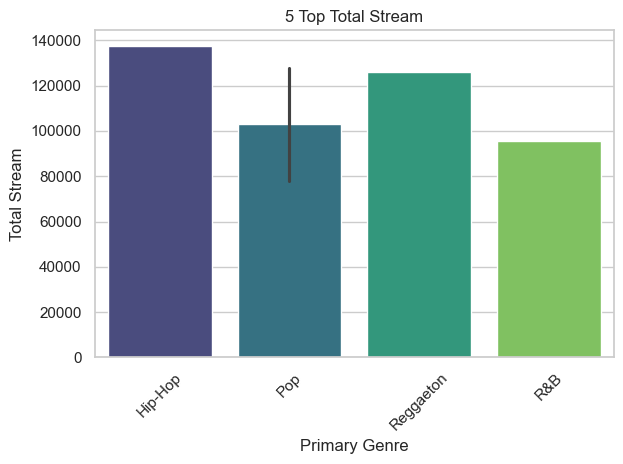

In [66]:
top5_genres = df.nlargest(5, "Total_Streams_(in_millions)")

sns.barplot(
    data=top5_genres,
    x="Primary_Genre",
    y="Total_Streams_(in_millions)",
    palette="viridis"
)
plt.xticks(rotation=45)
plt.title("5 Top Total Stream")
plt.ylabel("Total Stream")
plt.xlabel("Primary Genre")
plt.tight_layout()
plt.show()

DIBAWAH INI ADALAH CONTOH VISUALISASI TOTAL STREAM DARI SEMUA GENRE YANG ADA DI SPOTIFY

In [49]:
genre = pd.pivot_table(df,index='Primary_Genre', 
 values='Total_Streams_(in_millions)', 
 aggfunc=np.sum).sort_values(by='Total_Streams_(in_millions)', 
 ascending=False).reset_index()
genre

C:\Users\USER\AppData\Local\Temp\ipykernel_21900\3844189162.py:1: FutureWarning: The provided callable <function sum at 0x0000025BE908C3A0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  genre = pd.pivot_table(df,index='Primary_Genre',


,Primary_Genre,Total_Streams_(in_millions)
0,Hip-Hop,2126055.1
1,Pop,2003601.8
2,Reggaeton,888855.1
3,Rock,812082.6
4,R&B,570698.4
5,Latin,377962.0
6,EDM,367096.9
7,Regional Mexican,256013.5
8,K-Pop,157338.7
9,Filmi,151357.9


<function matplotlib.pyplot.show(close=None, block=None)>

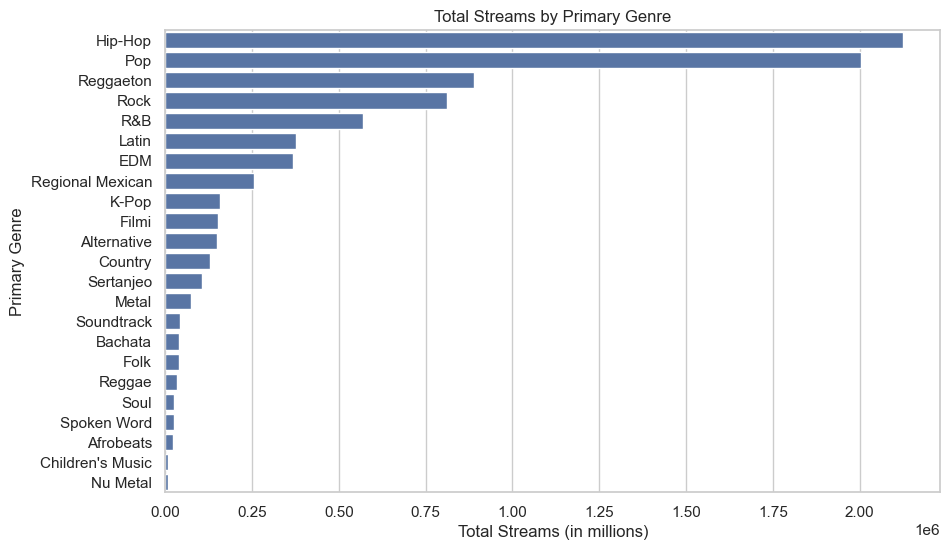

In [62]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Total_Streams_(in_millions)', 
    y='Primary_Genre', 
    data=genre)

plt.xlabel('Total Streams (in millions)')
plt.ylabel('Primary Genre')
plt.title('Total Streams by Primary Genre')
plt.show

TOP 5 POP 

In [96]:
pop = df[df['Primary_Genre'] == 'Pop'][['Artist_Name', 'Total_Streams_(in_millions)']]
pop.head(5)

,Artist_Name,Total_Streams_(in_millions)
1,Taylor Swift,127861.0
4,Justin Bieber,78104.4
5,Ariana Grande,68298.9
8,Ed Sheeran,64656.9
10,Rihanna,60670.7


C:\Users\USER\AppData\Local\Temp\ipykernel_21900\4012793175.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(pop.head(5), x='Artist_Name', y='Total_Streams_(in_millions)', palette='Blues_d')


Text(0.5, 1.0, 'Top 5 Pop Artists by Total Streams')

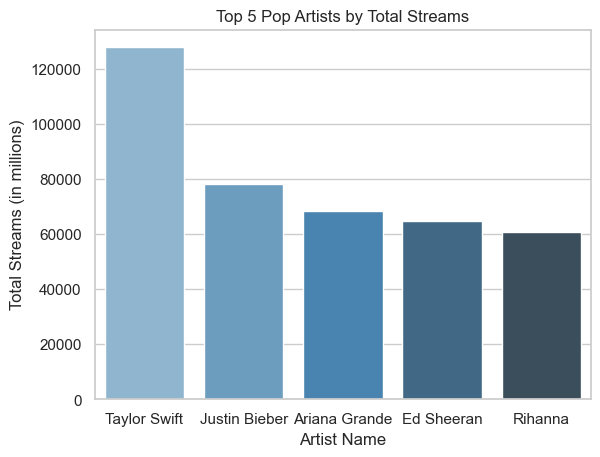

In [95]:
sns.barplot(pop.head(5), x='Artist_Name', y='Total_Streams_(in_millions)', palette='Blues_d')
plt.xlabel('Artist Name')
plt.ylabel('Total Streams (in millions)')
plt.title('Top 5 Pop Artists by Total Streams')

TAYLOR SWITFT TERLIHAT MASSIVE

In [98]:
df.head()

,Artist_Name,Sex,Country_of_Origin,Primary_Language,Primary_Genre,Artist_Type,Debut_Year,Total_Streams_(in_millions),Lead_Streams_(in_millions),Feature_Streams_(in_millions),Solo_Streams_(in_millions),%_of_Solo_Streams,Collaborative_Streams_(in_millions),%_of_Collaborative_Streams
0,Drake,Male,Canada,English,Hip-Hop,Solo,2006,137492.1,94851.1,42640.9,53323.9,38.783246,84168.2,61.216754
1,Taylor Swift,Female,United States,English,Pop,Solo,2006,127861.0,126177.3,1683.8,113421.5,88.706877,14439.5,11.293123
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,2013,125899.8,82189.3,43710.5,48887.0,38.830086,77012.8,61.169914
3,The Weeknd,Male,Canada,English,R&B,Solo,2009,95703.2,77189.4,18513.8,51020.0,53.310652,44683.2,46.689348
4,Justin Bieber,Male,Canada,English,Pop,Solo,2009,78104.4,48316.2,29788.2,29638.3,37.947030,48466.1,62.052970


C:\Users\USER\AppData\Local\Temp\ipykernel_21900\2716914000.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=debut.index, y=debut.values, palette='viridis')


Text(0.5, 1.0, 'Top 10 Debut Years with Most Artists')

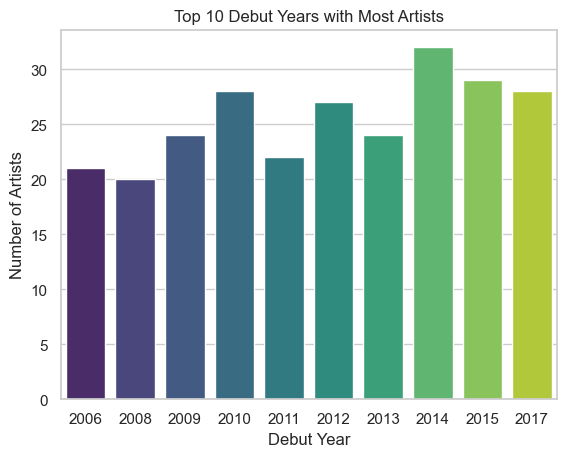

In [154]:
debut = df['Debut_Year'].value_counts().head(10)

sns.barplot(x=debut.index, y=debut.values, palette='viridis')
plt.xlabel('Debut Year')   
plt.ylabel('Number of Artists')
plt.title('Top 10 Debut Years with Most Artists')


melihat perkembangan debut genre tahun per tahun

In [152]:
genre_growth = df[(df['Primary_Genre'] == 'Pop') & (df['Debut_Year'] >= 2006)][['Debut_Year', 'Total_Streams_(in_millions)']].groupby('Debut_Year').sum().reset_index()
genre_growth.head()

,Debut_Year,Total_Streams_(in_millions)
0,2006,187155.9
1,2007,42290.4
2,2008,151736.9
3,2009,136289.7
4,2010,135552.6


Text(0.5, 1.0, 'Total Streams of Pop Artists by Debut Year (2006 and later)')

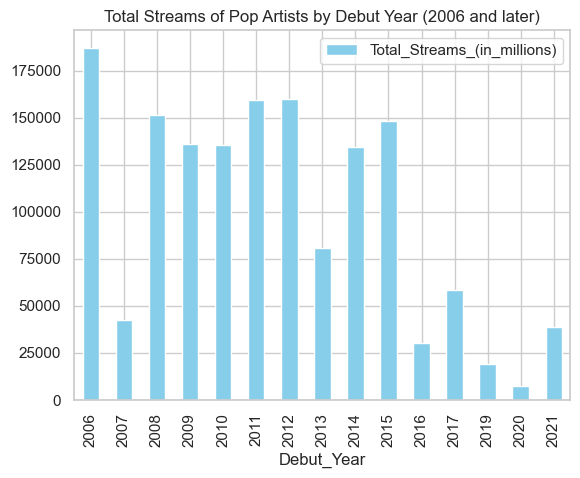

In [153]:
genre_growth.plot(x='Debut_Year', y='Total_Streams_(in_millions)', kind='bar', color='skyblue')
plt.title('Total Streams of Pop Artists by Debut Year (2006 and later)')